<a href="https://colab.research.google.com/github/Squirrelcoding/ISLP/blob/main/ISLP_Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

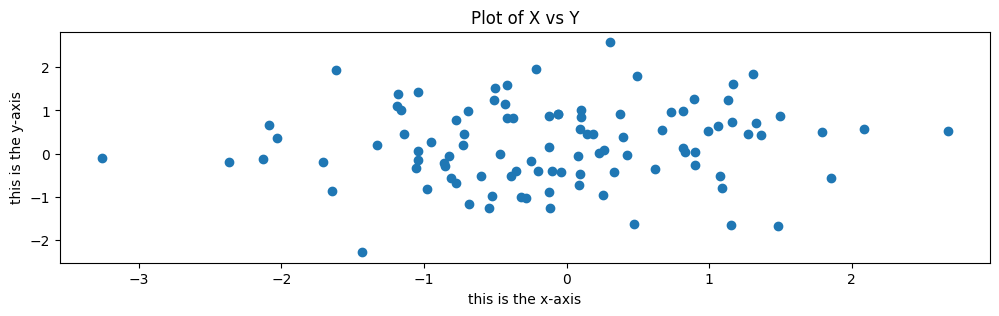

In [10]:
from matplotlib.pyplot import subplots

rng = np.random.default_rng(1303)

fig, ax = subplots(figsize=(8, 8))

x = rng.standard_normal(100)
y = rng.standard_normal(100)

ax.scatter(x, y, marker='o')

ax.set_xlabel('this is the x-axis')
ax.set_ylabel('this is the y-axis')
ax.set_title('Plot of X vs Y')

fig.set_size_inches(12, 3)

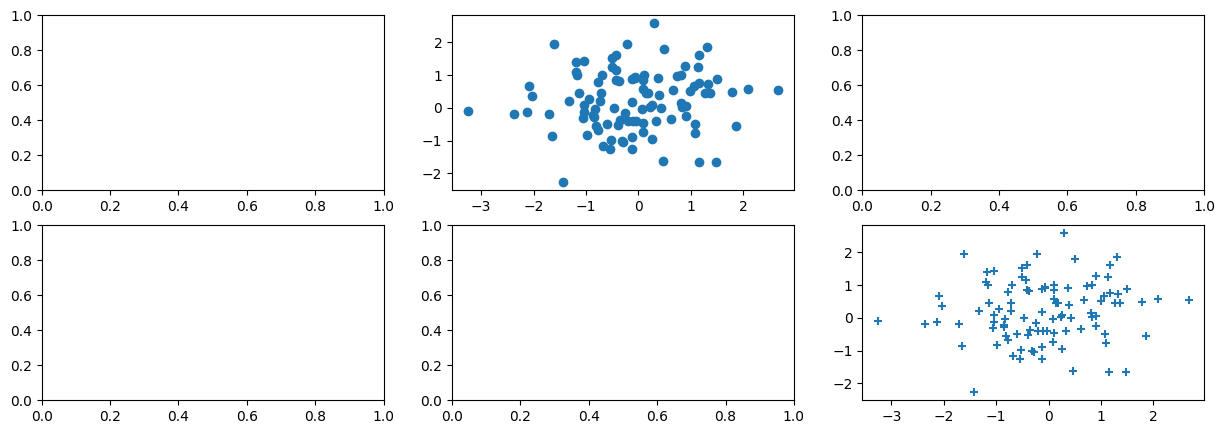

In [11]:
fig, axes = plt.subplots(nrows=2,
                         ncols=3,
                         figsize=(15,5),
                         )

axes[0, 1].plot(x, y, 'o')
axes[1, 2].scatter(x, y, marker='+')

In [12]:
fig.savefig('output.png', dpi=400)

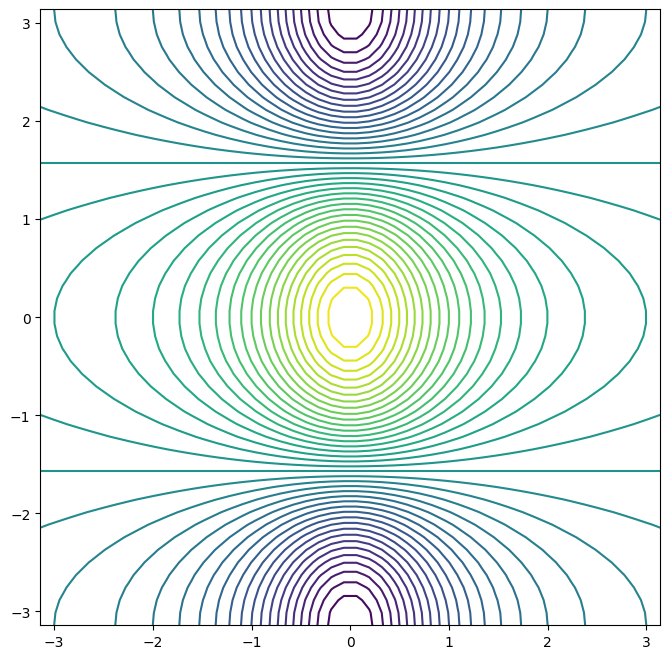

In [13]:
fig, ax = subplots(figsize=(8, 8))

x = np.linspace(-np.pi, np.pi, 50)
y = x

f = np.multiply.outer(np.cos(y), 1 / (1 + x**2))
ax.contour(x, y, f, levels=45)

In [14]:
ax.imshow(f)

# Exercises

## 1



* (a) Since we have a large amount of data and a small amount of predictors, an inflexible learning method would be better. This is because we have a large amount of data, letting the method converge closer to the true curve. The small number of predictors removes variability.

* (b) A flexible learning method would be better given the restricted nature of the data. An inflexible learning method would likely not be able to meaningfully converge to the true function.

* (c) A flexible learning method would be better since a highly nonlinear relationship is difficult to model with inflexible methods.

* (d) An inflexible learning method would be better since flexible learning methods are more sensitive to the random noise, and may overfit.


## 2

- (a) This is a regression problem with $n=500$ and $p = 3$ since the predictors are profit, number of employees, and industry. Since we are interested in understanding which factors affect CEO salary, this is an inference problem.

- (b) This is a binary classification problem with $n=20$ and $p=13$. Since we only wish to know if it is a success or failure, it is a prediction problem.

- (c) This is a regression problem with $n=52$ and $p=3$. We want to predict a quantity, so it is a prediction problem.

## 3

- done on paper

## 4

- (a) A disease given a list of factors such as age, gender, and previous conditions. Whether a bodybuilder is natural given their statistics (age, bench PR, etc.) over time. Identifying unusual behavior given location over time.

- (b) Predicting when a storm will hit given past behavior, future stock prices given past prices, and number of people in need during a natural disaster given the area and damages.

- (c) Categorizing architecture of buildings, grouping together similar items in a database, and categorizing people on social media. Basically anything that has to do with categorizing things that do not have clear boundaries.



## 5

The advantages of a very flexible approach for regression include being able to model highly nonlinear data and having low bias. However, it has high variance, meaning it is easy to overfit and may sometimes generalize poorly in regression. In classification, it may draw curves that overfit the data so it may suffer the same issues. Less flexible data has the opposite advantages/disadvantages.

It is more appropriate to use a very flexible model when the variance in the data is high, it is highly nonlinear, or if it has a large number of predictors with few observation points.

Less flexible models are also preferred in inference due to their simple nature and easy interpretability.

## 6

A parametric statistical learning approach involves estimating the weights of a function whose form is pre-determined such that a loss function is minimized. For example, the function may be $f(x) = a_1 x_1 + a_2 x_2 + a_3 x_3 + a_4 x_4$ and we may want to learn the weights for the $a_i$. The process of learning the weights is called *training* and this is not found in non-parametric statistical learning approaches.

Non-parametric statistical learning approaches do not assume anything about the form of $f$ (the function that minimizes the loss function). They instead seek an estimate of $f$ that is not too wiggly or rough and can accurately model lots of data.


The advantages of a parametric approach is that the assumption of the form of $f$ can help the model predict the test data better than a non-parametric model. Parametric models have low variance unlike their non-parametric counterparts. Choosing the wrong pre-determined form can have the opposite effect.

## 7



In [15]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array(
    [
      [0, 0, 0],
      [0, 3, 0],
      [2, 0, 0],
      [0, 1, 3],
      [0, 1, 2],
      [1, 1, 1],
    ]
)

n = data.shape[0]


distances = {}

for i in range(n):
  distances[i] = []
  for j in range(n):
    if i != j:
      distances[i].append(
          (np.linalg.norm(data[i] - data[j]), data[j])
      )

for i in range(n):
  distances[i].sort(key=lambda x: x[0])

# Print out the K nearest points for each point in the data
K = 3

for i in range(n):
  min_index = 0
  for j in range(3):
    if distances[i][j][0] != 0:
      print(f"{data[i]} | {distances[i][j]}")
  print()

[0 0 0] | (np.float64(1.7320508075688772), array([1, 1, 1]))
[0 0 0] | (np.float64(2.0), array([2, 0, 0]))
[0 0 0] | (np.float64(2.23606797749979), array([0, 1, 2]))

[0 3 0] | (np.float64(2.449489742783178), array([1, 1, 1]))
[0 3 0] | (np.float64(2.8284271247461903), array([0, 1, 2]))
[0 3 0] | (np.float64(3.0), array([0, 0, 0]))

[2 0 0] | (np.float64(1.7320508075688772), array([1, 1, 1]))
[2 0 0] | (np.float64(2.0), array([0, 0, 0]))
[2 0 0] | (np.float64(3.0), array([0, 1, 2]))

[0 1 3] | (np.float64(1.0), array([0, 1, 2]))
[0 1 3] | (np.float64(2.23606797749979), array([1, 1, 1]))
[0 1 3] | (np.float64(3.1622776601683795), array([0, 0, 0]))

[0 1 2] | (np.float64(1.0), array([0, 1, 3]))
[0 1 2] | (np.float64(1.4142135623730951), array([1, 1, 1]))
[0 1 2] | (np.float64(2.23606797749979), array([0, 0, 0]))

[1 1 1] | (np.float64(1.4142135623730951), array([0, 1, 2]))
[1 1 1] | (np.float64(1.7320508075688772), array([0, 0, 0]))
[1 1 1] | (np.float64(1.7320508075688772), array([2, 0,

A is done above.

(b) red
(c) red
(d) We would expect $K$ to be small because of the high variance. A smaller $K$ allows the model to be more flexible and adapt to the highly nonlinear boundary. A larger $K$ would group many neighbors under a single class while they may actually all belong to different classes despite them being close to each other. A highly nonlinaear boundary would be able to split them up without misclassifying them.

# 8

(a) We load in the data.

In [16]:
import pandas as pd

college = pd.read_csv("College.csv")

(b)

In [17]:
college2 = pd.read_csv('College.csv', index_col=0)

In [18]:
college3 = college.rename({'Unnamed: 0': 'College'}, axis=1)

college3

,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


In [19]:
college3 = college3.set_index('College')

In [20]:
college3

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49


In [21]:
college = college3

In [22]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


array([[<Axes: xlabel='Top10perc', ylabel='Top10perc'>,
        <Axes: xlabel='Apps', ylabel='Top10perc'>,
        <Axes: xlabel='Enroll', ylabel='Top10perc'>],
       [<Axes: xlabel='Top10perc', ylabel='Apps'>,
        <Axes: xlabel='Apps', ylabel='Apps'>,
        <Axes: xlabel='Enroll', ylabel='Apps'>],
       [<Axes: xlabel='Top10perc', ylabel='Enroll'>,
        <Axes: xlabel='Apps', ylabel='Enroll'>,
        <Axes: xlabel='Enroll', ylabel='Enroll'>]], dtype=object)

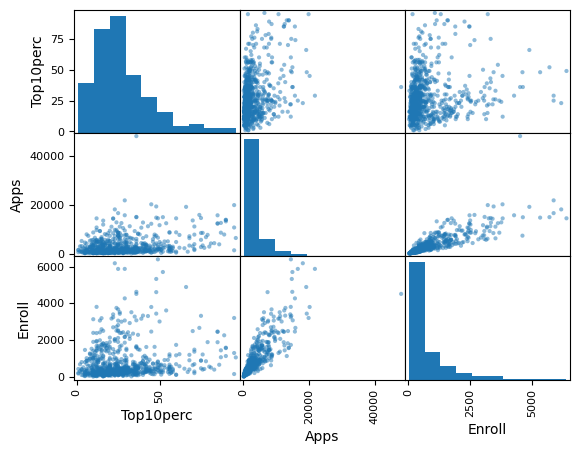

In [23]:
pd.plotting.scatter_matrix(college[['Top10perc', 'Apps', 'Enroll']])

In [24]:
import seaborn as sns


<Axes: xlabel='Private', ylabel='Outstate'>

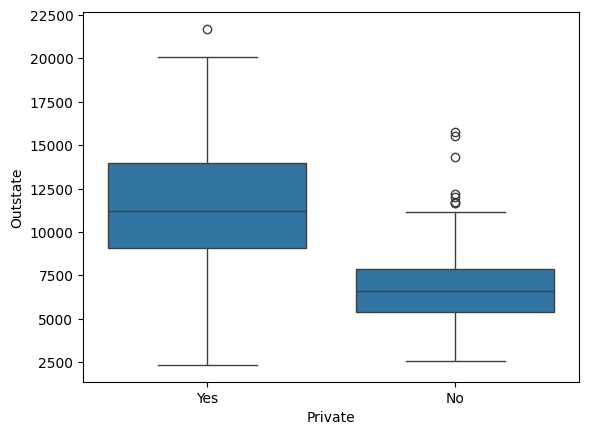

In [25]:
sns.boxplot(x='Private', y='Outstate', data=college)

In [26]:
college.loc[college['Top10perc'] > 50, 'Elite'] = 'Yes'
college['Elite'] = college['Elite'].fillna('No')


<Axes: xlabel='Elite', ylabel='Outstate'>

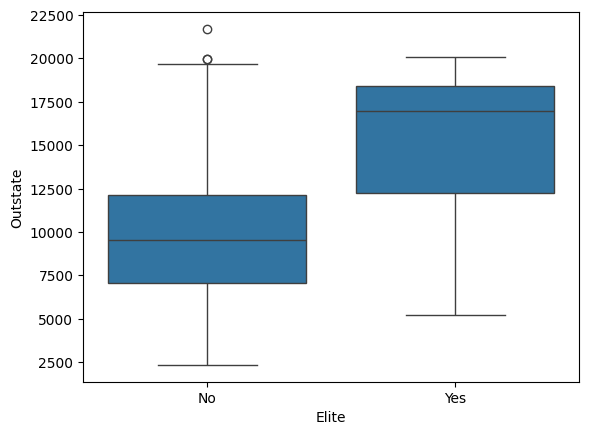

In [27]:
sns.boxplot(x='Elite', y='Outstate', data=college)

<Axes: >

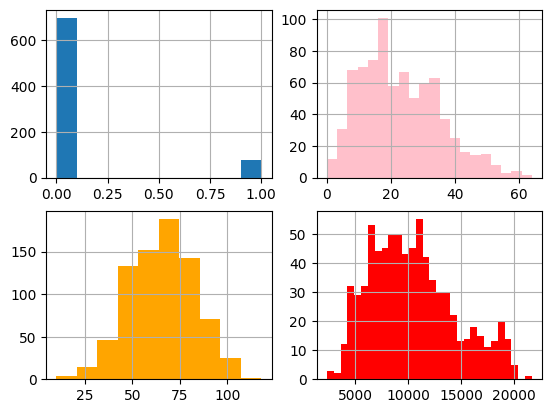

In [74]:
fig, ax = plt.subplots(2, 2)

college['Elite_bins'] = pd.cut(college['Top10perc'], [0, 0.5, 1], labels=['No', 'Yes'])

# fig[0][0] = college.hist(column='Elite')

college['Elite'].map({'Yes': 1, 'No': 0}).hist(bins=10, ax=ax[0, 0])
college['Grad.Rate'].hist(bins=10, ax=ax[1, 0], color='orange')
college['Outstate'].hist(bins=30, ax=ax[1, 1], color='red')
college['perc.alumni'].hist(bins=20, ax=ax[0, 1], color='pink')


<Axes: >

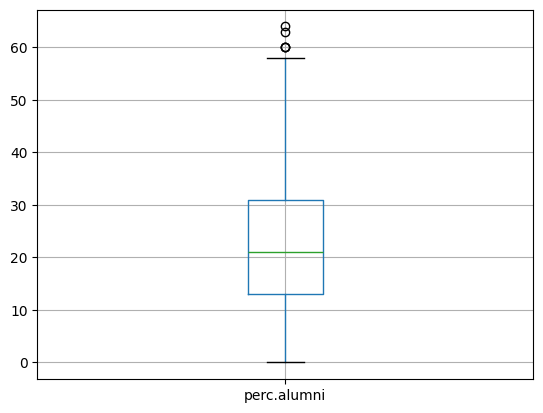

In [80]:
# Box plot of percent of alumni who donate to their alma mater

college.boxplot(column='perc.alumni')

In [81]:
college['perc.alumni'].describe()

,perc.alumni
count,777.000000
mean,22.743887
std,12.391801
min,0.000000
25%,13.000000
50%,21.000000
75%,31.000000
max,64.000000


The bottom 25% of the schools have at most 13% of their alumni donate.

The next fourth of schools have 13-21% of their alumni donate.

The third fourth of schoosl have 23-31% of alumni donate.

The top fourth of cshools have 31-64% of alumni donate. This is very rare since the mean is only 22.7%.

<Axes: xlabel='Expend', ylabel='Top10perc'>

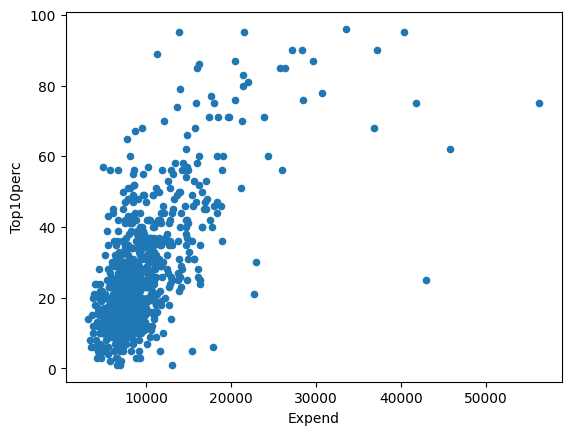

In [85]:
college.plot.scatter(x='Expend', y='Top10perc')

Here there is a strong relationship between how expensive a college is and the percentage of students who graduated in the top 10% of their high school class. The closer to the bottom right a point is, the less it is worth and vice versa.

# (9) Auto Dataset

In [87]:
# Load in th edata

auto = pd.read_csv('Auto.csv')

In [91]:
auto.describe()

,mpg,cylinders,displacement,weight,acceleration,year,origin
count,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000
mean,23.515869,5.458438,193.532746,2970.261965,15.555668,75.994962,1.574307
std,7.825804,1.701577,104.379583,847.904119,2.749995,3.690005,0.802549
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.000000,2223.000000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,146.000000,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3609.000000,17.100000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


- (a) The quantitative predictors are mpg, cylinders, displacement, horsepower, weight, acceleration, year, and origin. The only qualtitative variable is name.

In [117]:
# (b)

a = auto.describe()

a['range'] = a.loc['max'] - a.loc['min']

a.loc['mean']
# a.loc['std']

,mean
mpg,23.515869
cylinders,5.458438
displacement,193.532746
weight,2970.261965
acceleration,15.555668
year,75.994962
origin,1.574307
range,NaN


In [111]:
a['std']

,std
count,NaN
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [140]:
dropped = auto.drop(auto.index[11:86]).describe()

In [146]:
b = dropped.describe()

b.loc['max'] - b.loc['min']

,0
mpg,314.094845
cylinders,320.342602
displacement,387.000000
weight,4675.000000
acceleration,319.279113
year,318.851408
origin,321.184428
range,NaN


<Axes: xlabel='weight', ylabel='mpg'>

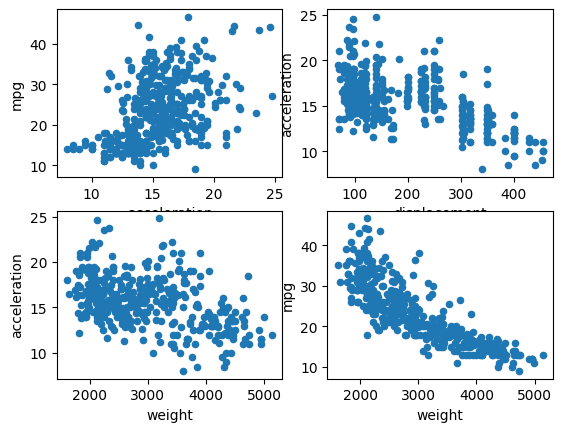

In [171]:
fig, ax = plt.subplots(2, 2)

auto.plot.scatter(x='acceleration', y='mpg', ax=ax[0, 0])
auto.plot.scatter(x='displacement', y='acceleration', ax=ax[0, 1])
auto.plot.scatter(x='weight', y='acceleration', ax=ax[1, 0])
auto.plot.scatter(x='weight', y='mpg', ax=ax[1, 1])